# Water Allocation Simulation Analysis
This notebook provides tools to analyze the results of the water allocation simulation
across multiple scenarios, focusing on ecological and economic impacts under different
conditions.

## Overview
The simulation tests water allocation policies across various scenarios with different:
- River basins (station configurations)
- Actor compositions
- Water scarcity levels
- Forecast error profiles (bias and uncertainty)

The analysis evaluates how these factors affect both ecological integrity and economic benefits.


In this notebook we will:
1. Run the set of evaluation scenarios varying station size, scarcity level,  
   forecast bias and uncertainty.
2. Collect ecological and economic impact metrics for each run.
3. Visualize trade-offs and explore how model parameters influence outcomes.

760

In [36]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from types import MethodType
import src.core as wms
import src.plot_analysis as gtp
import src.utils as utils
import src.policies.incentive_policies as eip
import src.policies.quota_policies as eqp
import src.scenarios as sc
import src.plot_multi_analysis as pma

# Set better visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100


In [37]:
# Define quota policy - determines how much water each actor is allowed to pump
# This uses the hard_quota policy from the quota_policies module
# In crisis situations, actors with priority below the crisis level get zero quota

def custom_quota(
    self,
    crisis_level: int,
    actors_priority: np.ndarray,
    avg_pump: np.ndarray,
    DOE: float,
    DCR: float,
) -> np.ndarray:
    priority_weights_1=0.5984838332004384
    priority_weights_2=0.2726664411087506
    priority_weights_3=1.4211296405877707
    compression_1=0.7021381013959085
    compression_2=0.1439255494194097
    compression_3=0.3844465144976456
    compression_4=0.4488361312435196
    priority_weights = (priority_weights_1, priority_weights_1+priority_weights_2, priority_weights_1+priority_weights_2+priority_weights_3)
    compression = (compression_1+compression_2+compression_3+compression_4,
                   compression_1+compression_2+compression_3,
                   compression_1+compression_2,
                   compression_1)
    weights = np.select(
        [actors_priority == 0, actors_priority == 1, actors_priority == 2],
        priority_weights
    )
    weighted_demand = avg_pump * weights
    total_weighted = np.sum(weighted_demand)

    total_available = np.sum(avg_pump) * compression[crisis_level] * 0.9
    quota = total_available * (weighted_demand / total_weighted)

    return np.clip(quota, 0.0, 1.2 * avg_pump)


def custom_incentive_policy(
    self,
    actions: np.ndarray,
    actors_priority: np.ndarray,
    avg_incomes: np.ndarray,
    water_pump: np.ndarray,
    avg_pump: np.ndarray,
    is_crisis: np.ndarray,
    water_flows: np.ndarray,
    quota: np.ndarray,
    DOE: float = 15,
    DCR: float = 10,
) -> np.ndarray:
    eco_alpha=2.951164369798566
    eco_beta=1.243923687349587
    fine_scale=1.007582757371356
    overuse_power=2.2350381182010137
    subsidy_low=0.7391821888277132
    penalty_low=1.1335955057300822
    penalty_medium=1.0022170966918416
    reward_onquota_low=0.008427389904452721
    reward_onquota_med=0.007170277608364876
    reward_onquota_high=0.029970840681204116
    fine_cap_factor=2.2064066712213544
    reward_onquota_med = reward_onquota_low+reward_onquota_med
    reward_onquota_high = reward_onquota_med+reward_onquota_high
    n = len(avg_incomes)
    incentives = np.zeros(n)

    current_flow = water_flows[-1]
    crisis_level = is_crisis[-1]
    eco_pressure = 1.0 + eco_alpha * max(0.0, (DOE - current_flow) / max(DOE - DCR, 1e-6)) ** eco_beta

    priority_penalty = np.select(
        [actors_priority == 0, actors_priority == 1, actors_priority == 2],
        [penalty_low, penalty_medium, 1.0]
    )
    reward_onquota = np.select(
        [actors_priority == 0, actors_priority == 1, actors_priority == 2],
        [reward_onquota_low, reward_onquota_med, reward_onquota_high]
    )

    for i in range(n):
        overuse = max(0.0, water_pump[i] - quota[i])
        if overuse > 0:
            penalty = fine_scale * (overuse ** overuse_power) / max(avg_pump[i], 1e-3)
            penalty *= eco_pressure * priority_penalty[i]

            if actors_priority[i] == 0:
                penalty = min(penalty, fine_cap_factor * max(avg_incomes[i], 1.0))

            incentives[i] = penalty

        elif water_pump[i] <= quota[i] * 0.9 and actors_priority[i] >= 1:
            incentives[i] = -reward_onquota[i] * max(avg_incomes[i], 0.0)

        elif crisis_level >= 1 and actors_priority[i] == 0:
            incentives[i] = -subsidy_low * max(avg_incomes[i], 0.0)

    return incentives


## Scenario Definition
Runs simulations across the pre-defined scenarios.
We iterate over:
- **Stations**: Tarn vs. La Vézère  
- **Scarcity levels**: low / medium / high  
- **2 set of actors and variant with heterogenous biaises and uncertainties**  
- **Forecast bias/uncertainty** settings  

Execute the next cell to proceed multo-scenario analysis.

In [38]:
if True:
    # results_df = sc.run_all_scenarios(
    #     turns=700,
    #     iterations=5,
    #     custom_incentive_policy=incentive_continuous,
    #     custom_quota=quota_dynamic)
    results_df = sc.run_all_scenarios(
        turns=700,
        iterations=5,
        custom_incentive_policy=custom_incentive_policy,
        custom_quota=custom_quota)
    results_df.to_csv('results_df.csv', index=False)
else:
# load results_df from csv
    results_df = pd.read_csv('results_df.csv')

Starting simulations across all scenarios...
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.879, Econ Impact: 0.857, Raw Eco Impact: 861.0, Cooperation %: 47.6%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.25, Eco Impact: 0.886, Econ Impact: 0.859, Raw Eco Impact: 867.0, Cooperation %: 43.3%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.5, Eco Impact: 0.870, Econ Impact: 0.857, Raw Eco Impact: 852.0, Cooperation %: 51.3%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.0, Eco Impact: 0.879, Econ Impact: 0.858, Raw Eco Impact: 861.0, Cooperation %: 46.0%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.25, Eco Impact: 0.880, Econ Impact: 0.859, Raw Eco Impact: 862.0, Cooperation %: 45.4%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.5, Ec


## Multi-Scenario Analysis


### Ecological vs. economic impact.

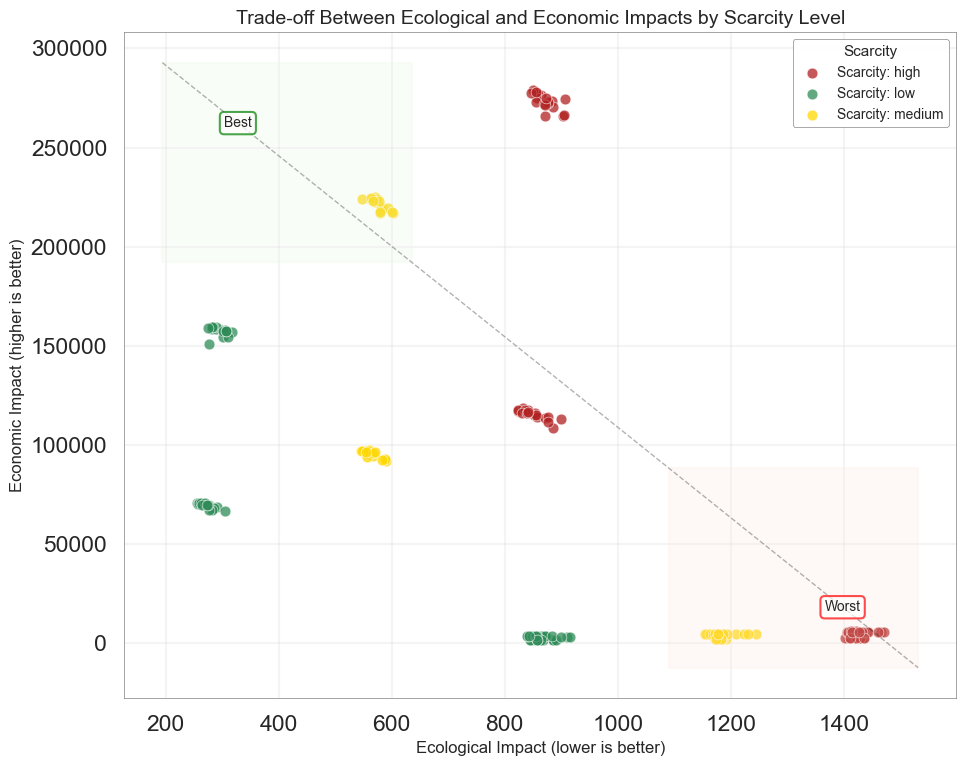

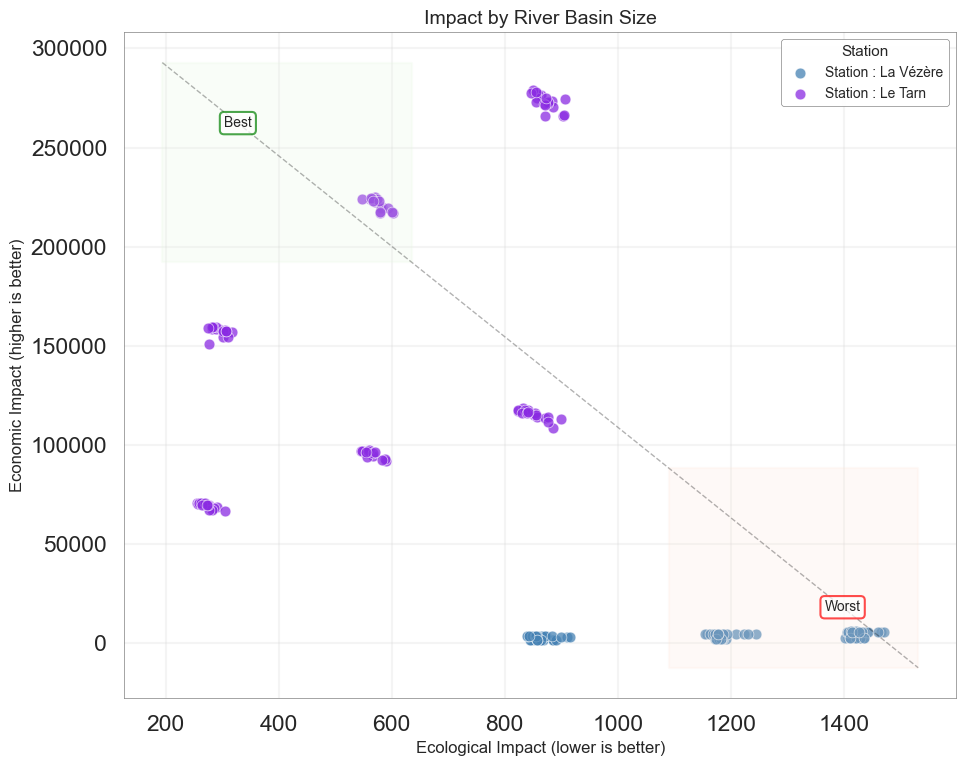

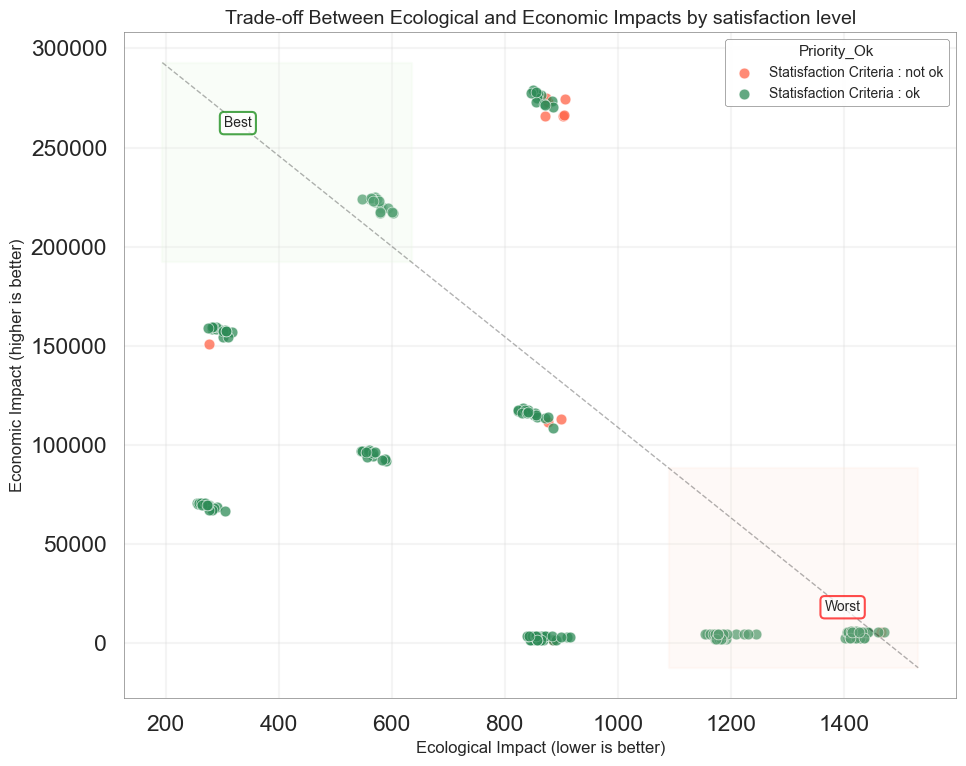

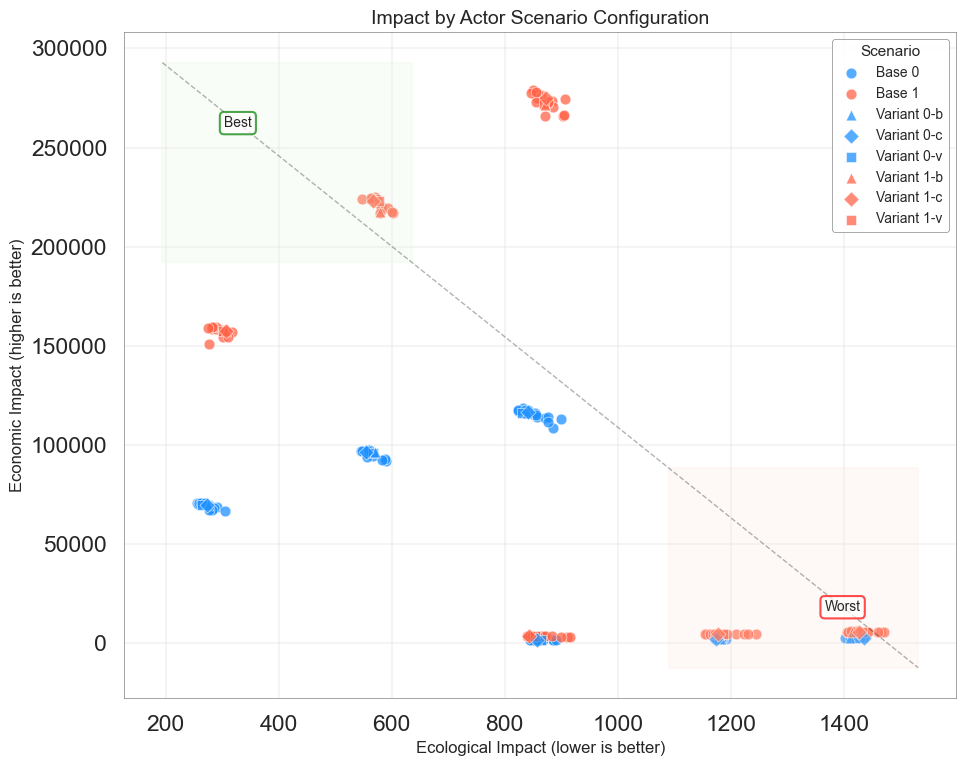

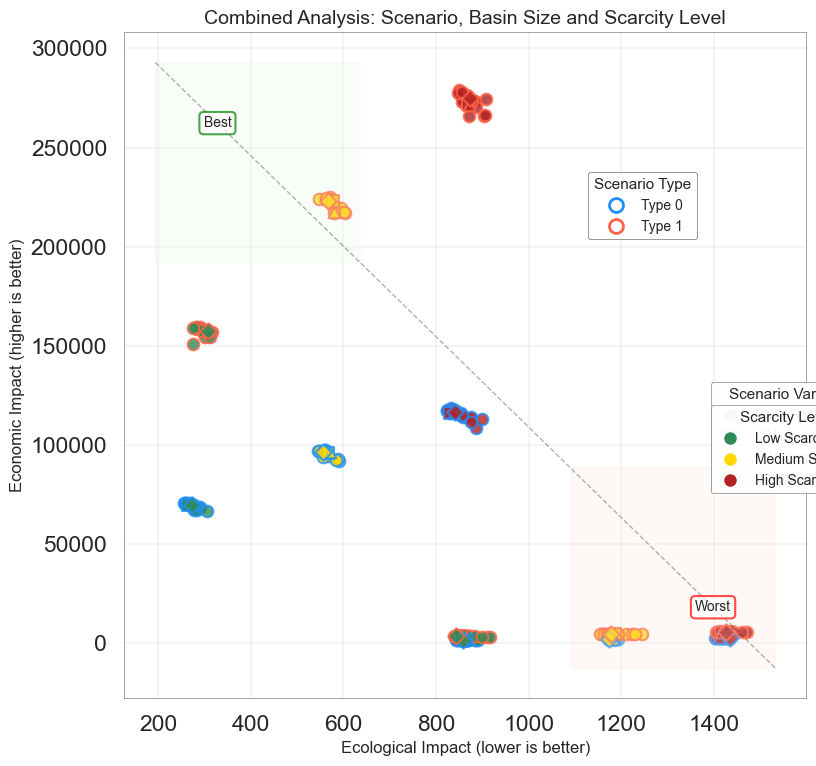

In [39]:
pma.analyze_scenario_impacts(results_df)

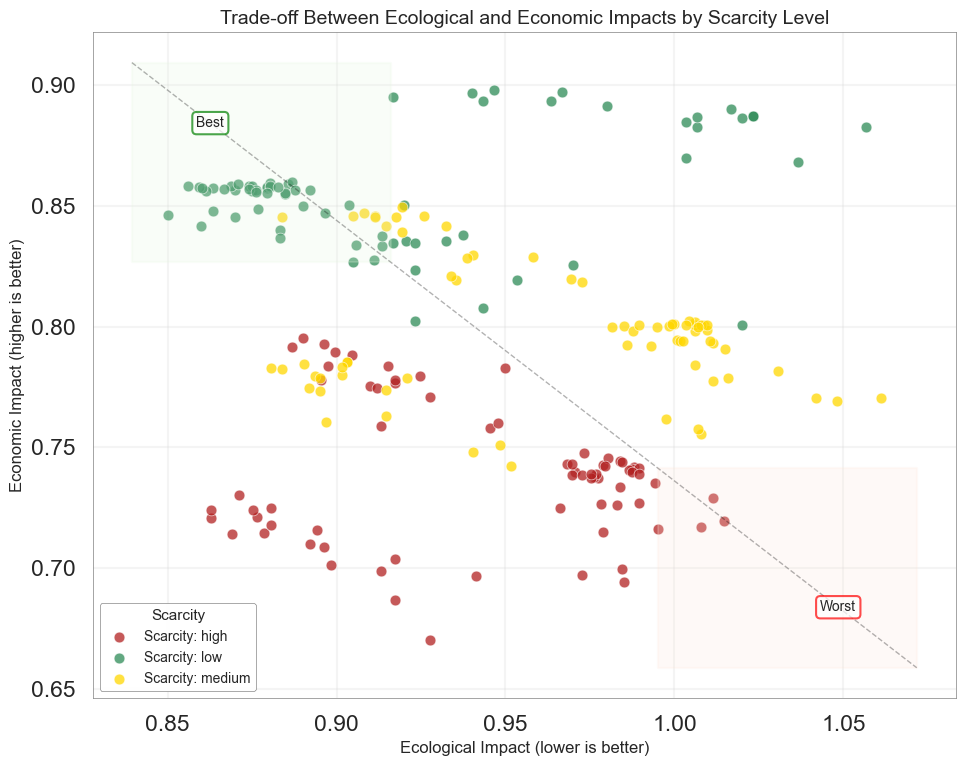

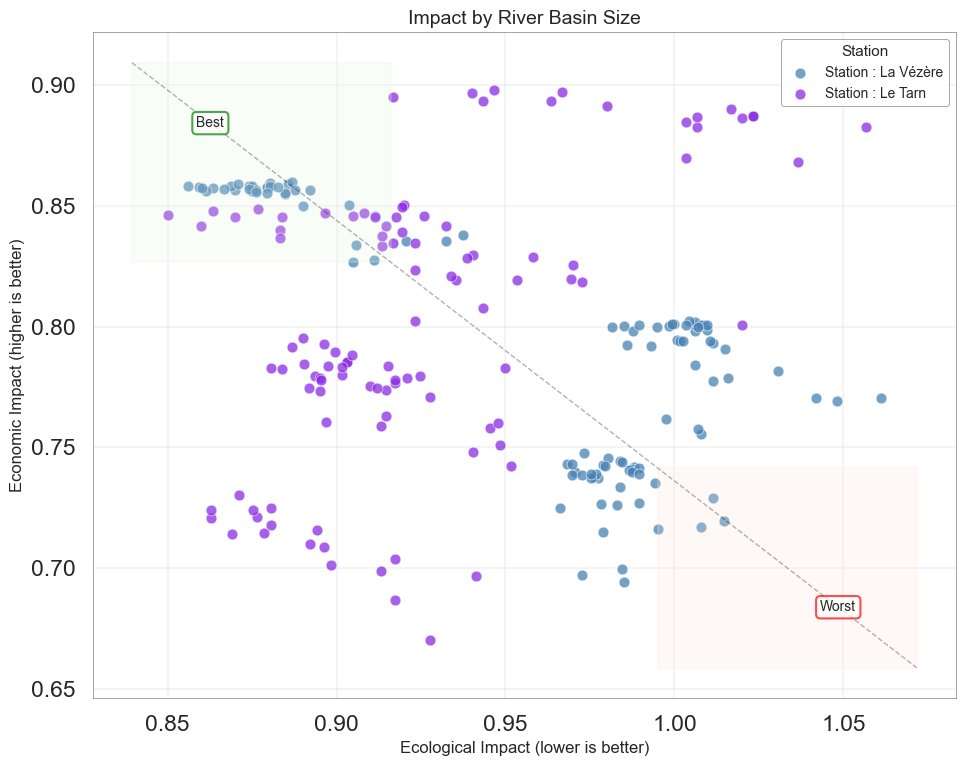

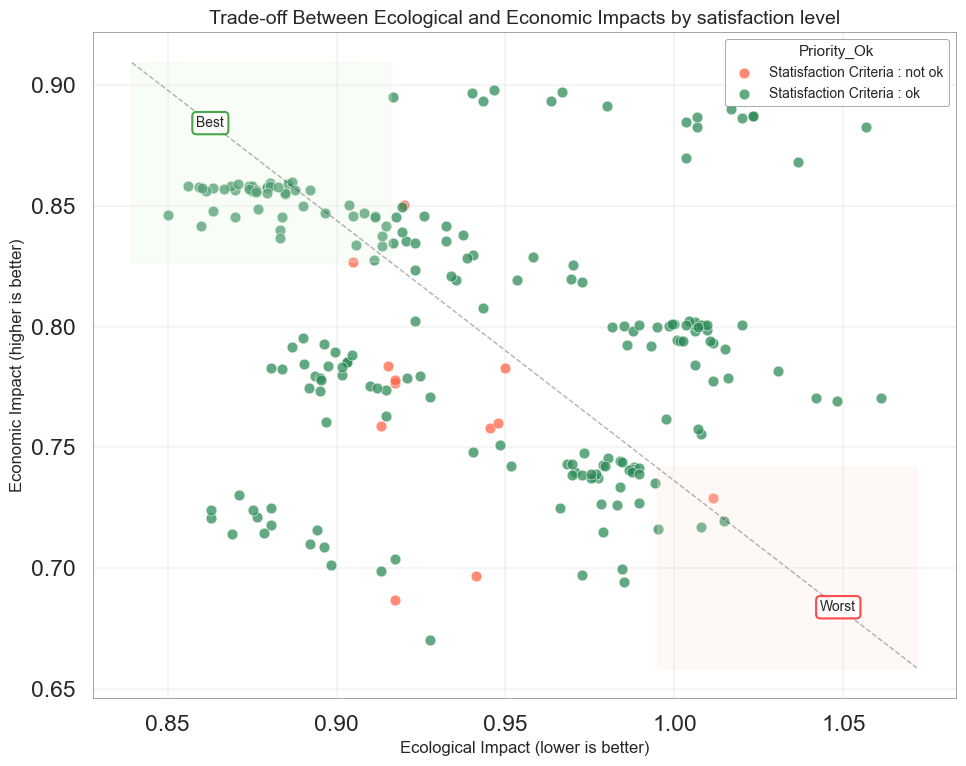

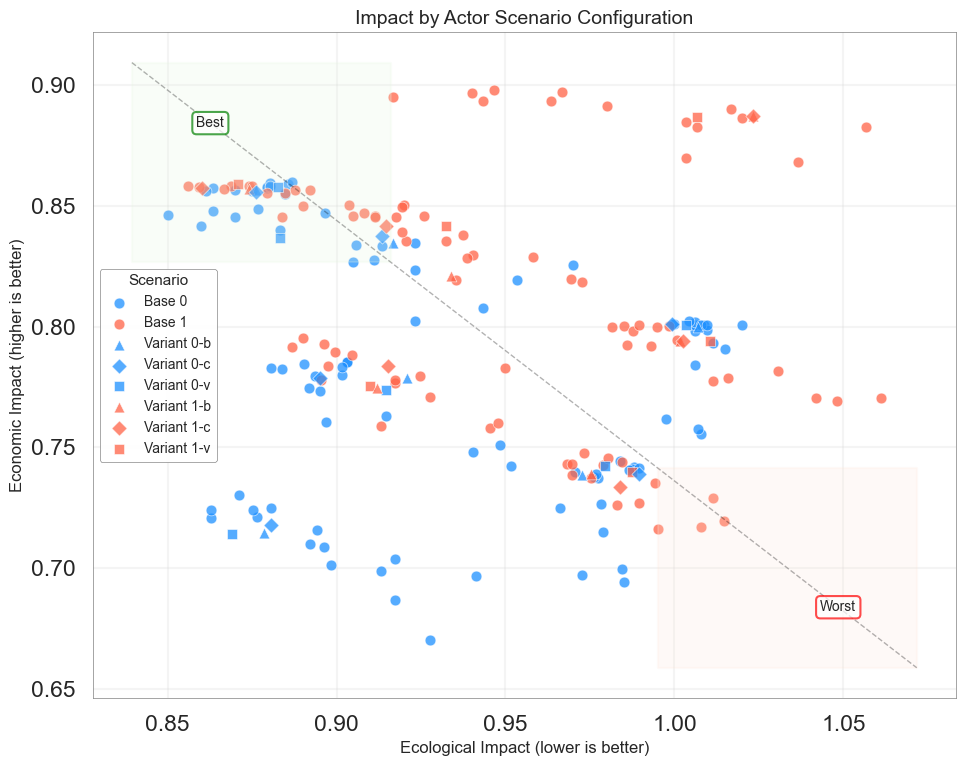

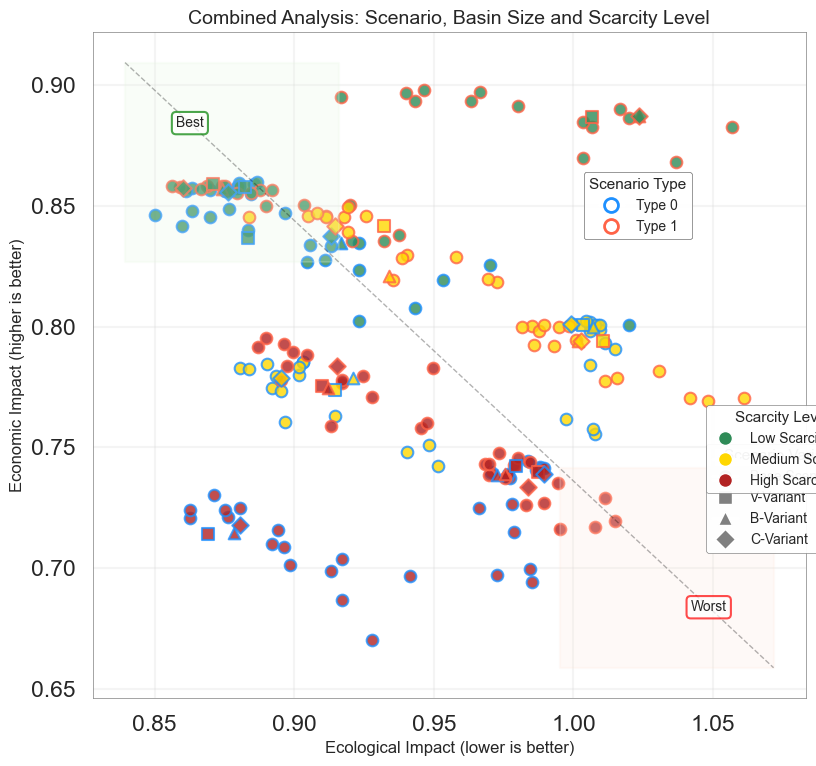

In [40]:
pma.analyze_scenario_impacts(results_df , is_scalled=True)

## Analyzing Forecast Bias & Uncertainty & Scarcity levels

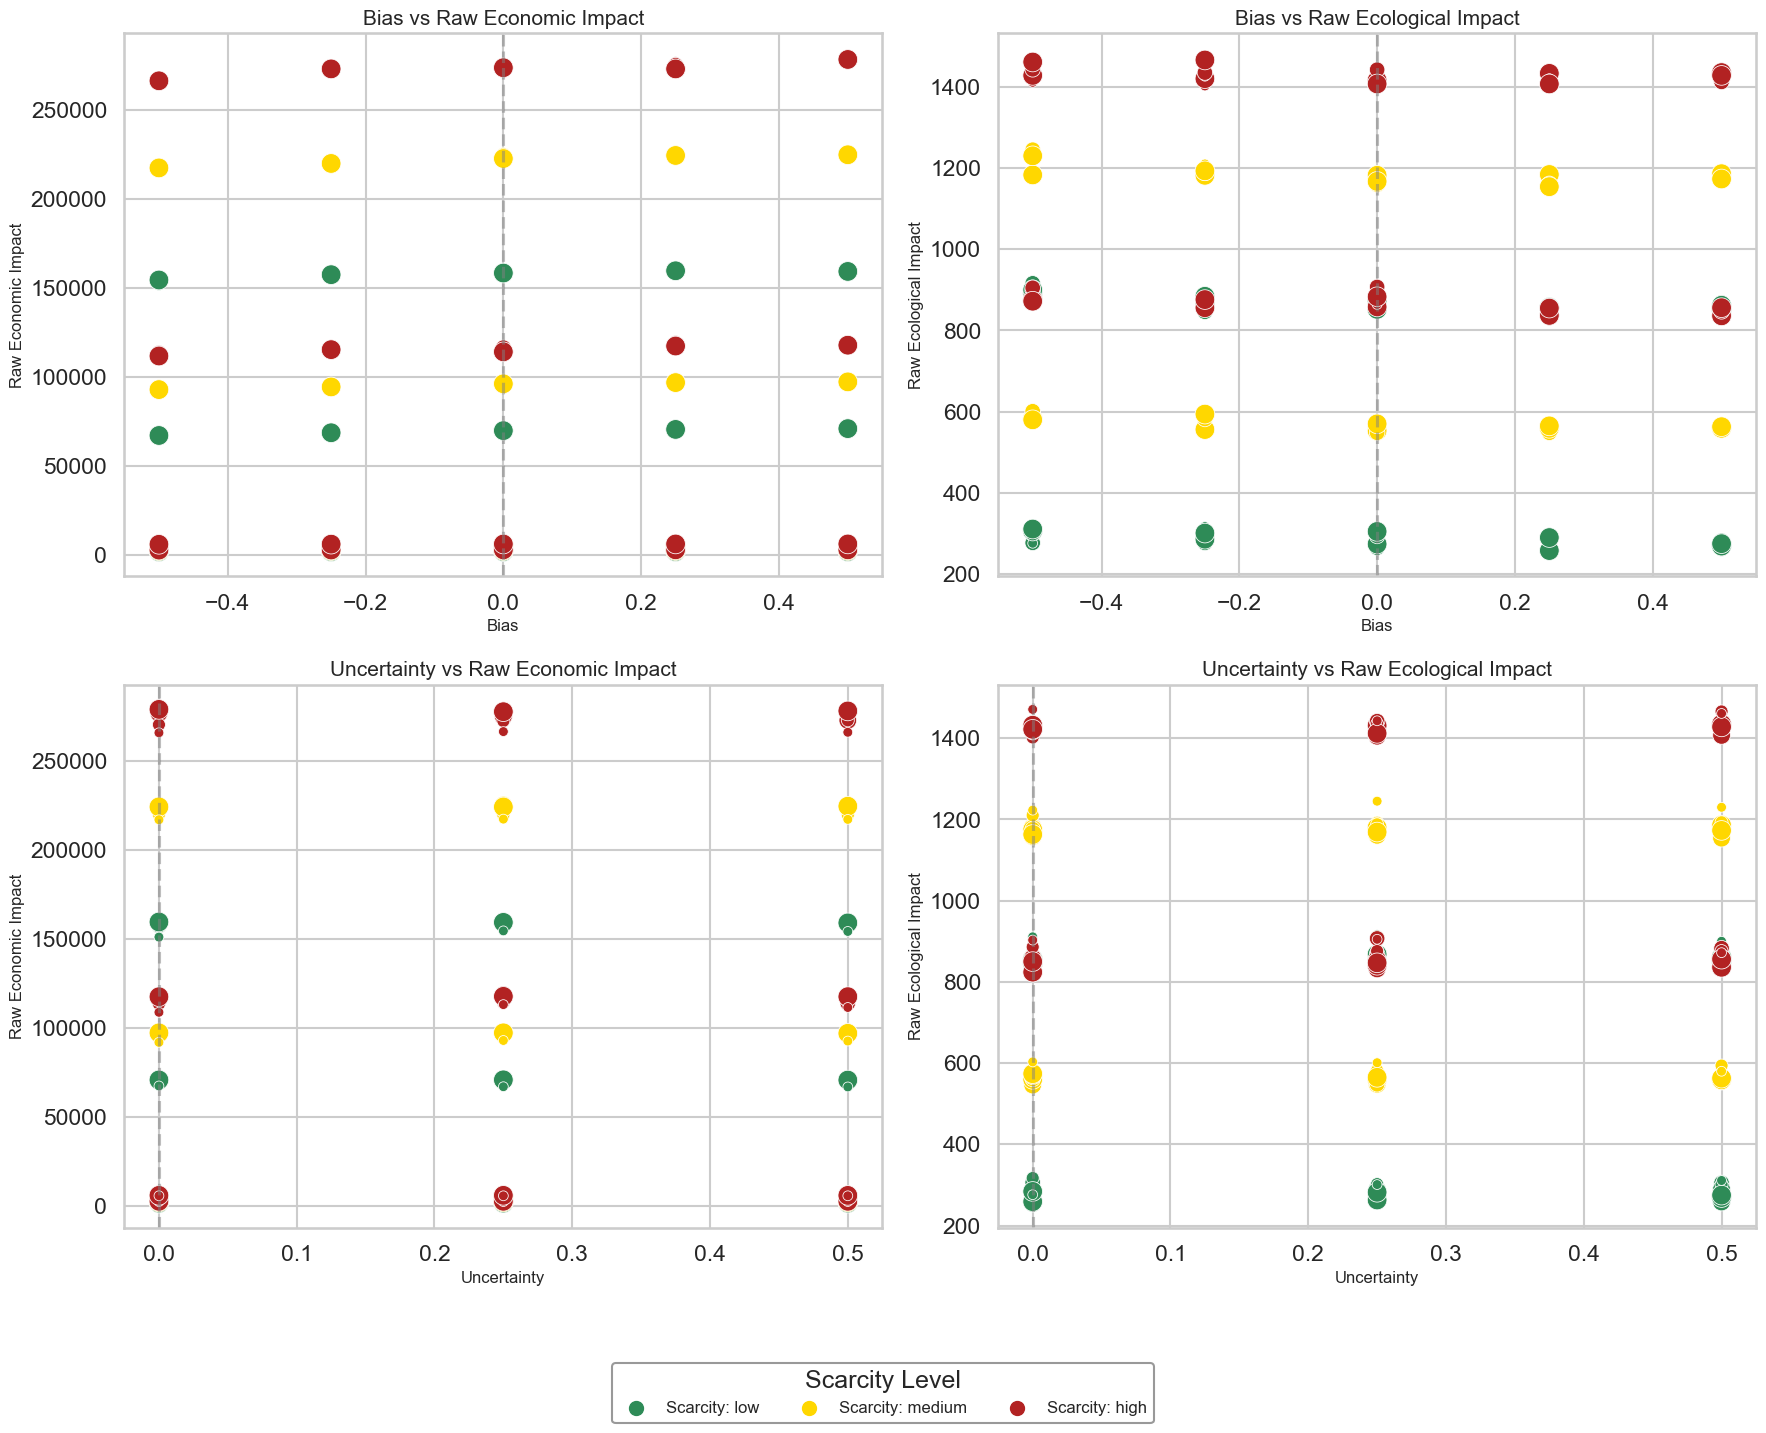

/Users/timo/PycharmProjects/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:419: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/timo/envirpython/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/timo/PycharmProjects/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:419: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/timo/envirpython/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with 

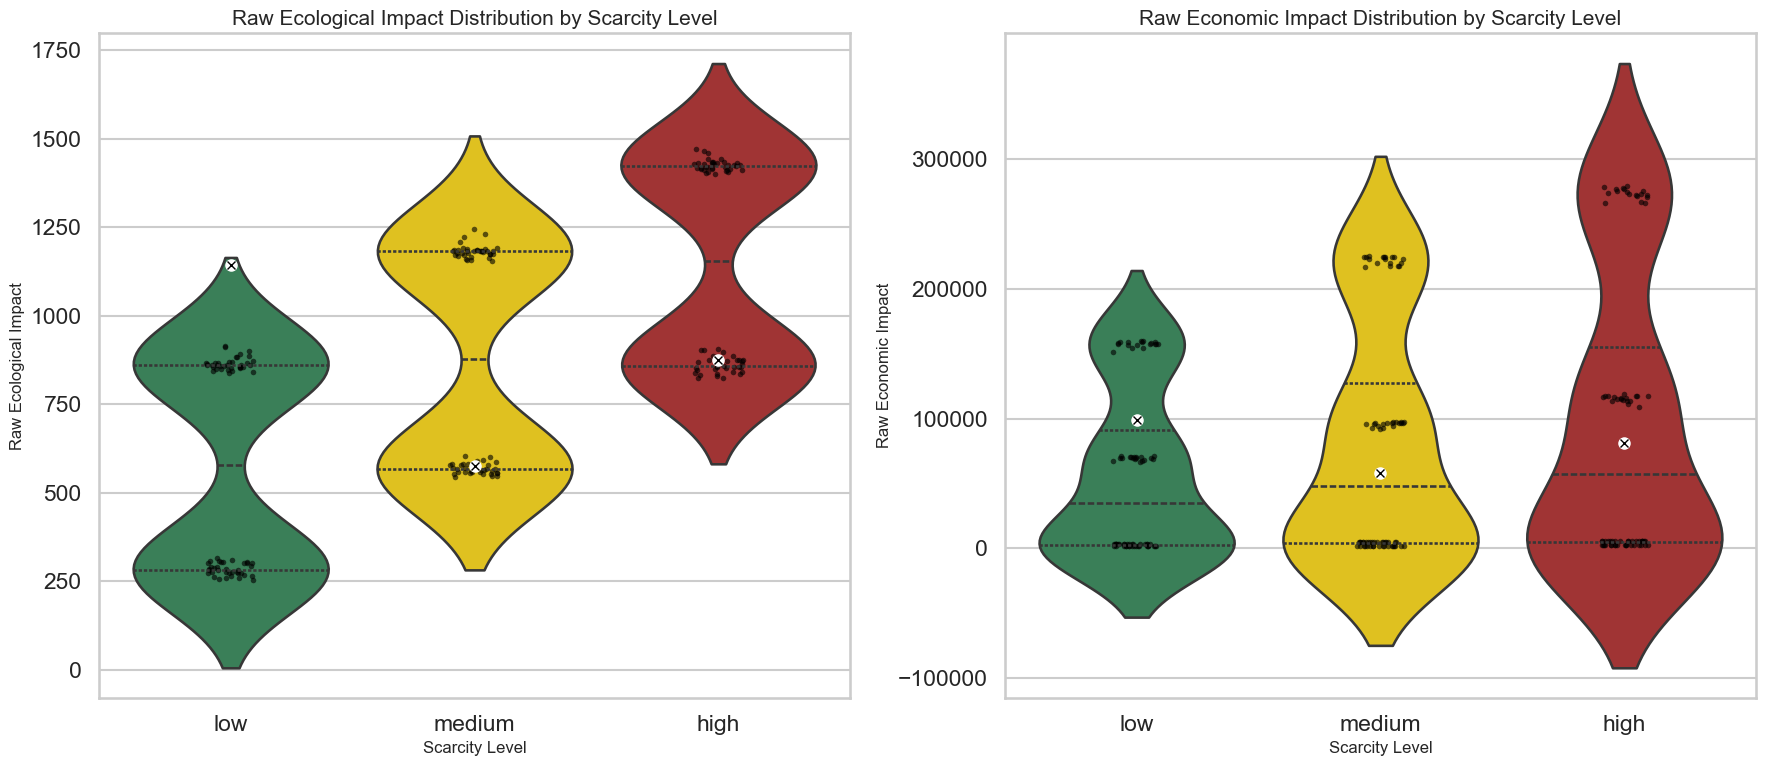

In [41]:
pma.analyze_forecast_effects(results_df)

## Correlation Analysis


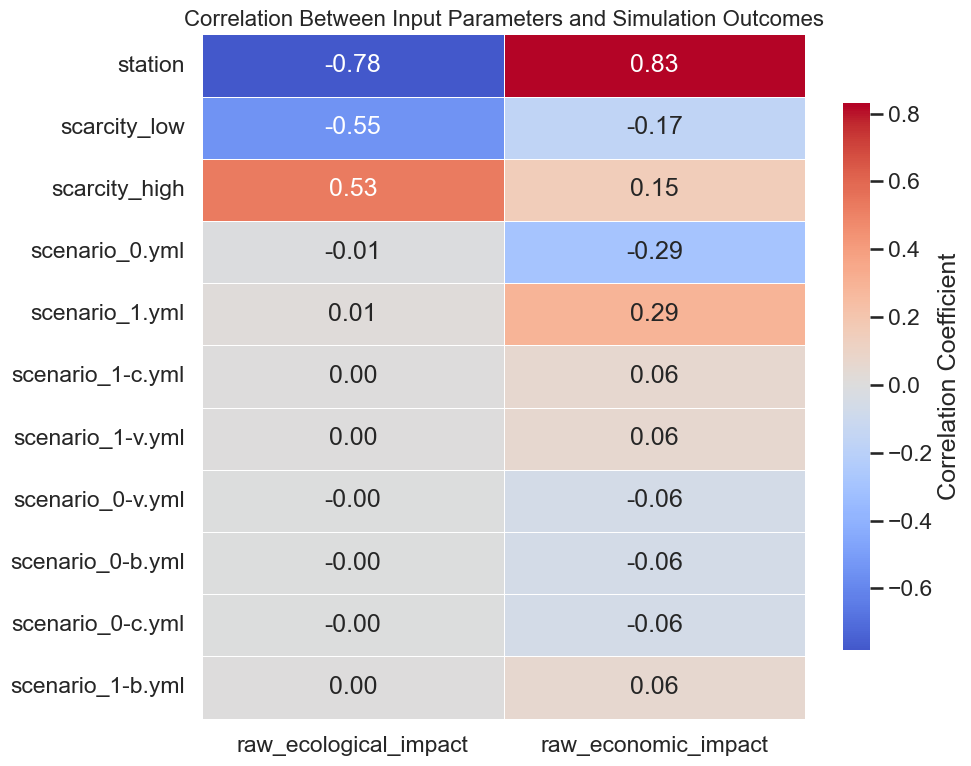


Top impacts on raw_ecological_impact:

Top 5 positive correlations:
  scarcity_high: 0.527
  scarcity_medium: 0.021
  scenario_1.yml: 0.014
  uncertainty: 0.003
  scenario_1-v.yml: 0.002

Top 5 negative correlations:
  scenario_0-v.yml: -0.005
  scenario_0.yml: -0.011
  bias: -0.028
  scarcity_low: -0.547
  station: -0.782

Top impacts on raw_economic_impact:

Top 5 positive correlations:
  station: 0.832
  scenario_1.yml: 0.293
  scarcity_high: 0.153
  scenario_1-c.yml: 0.060
  scenario_1-v.yml: 0.059

Top 5 negative correlations:
  scenario_0-c.yml: -0.058
  scenario_0-b.yml: -0.058
  scenario_0-v.yml: -0.058
  scarcity_low: -0.166
  scenario_0.yml: -0.293


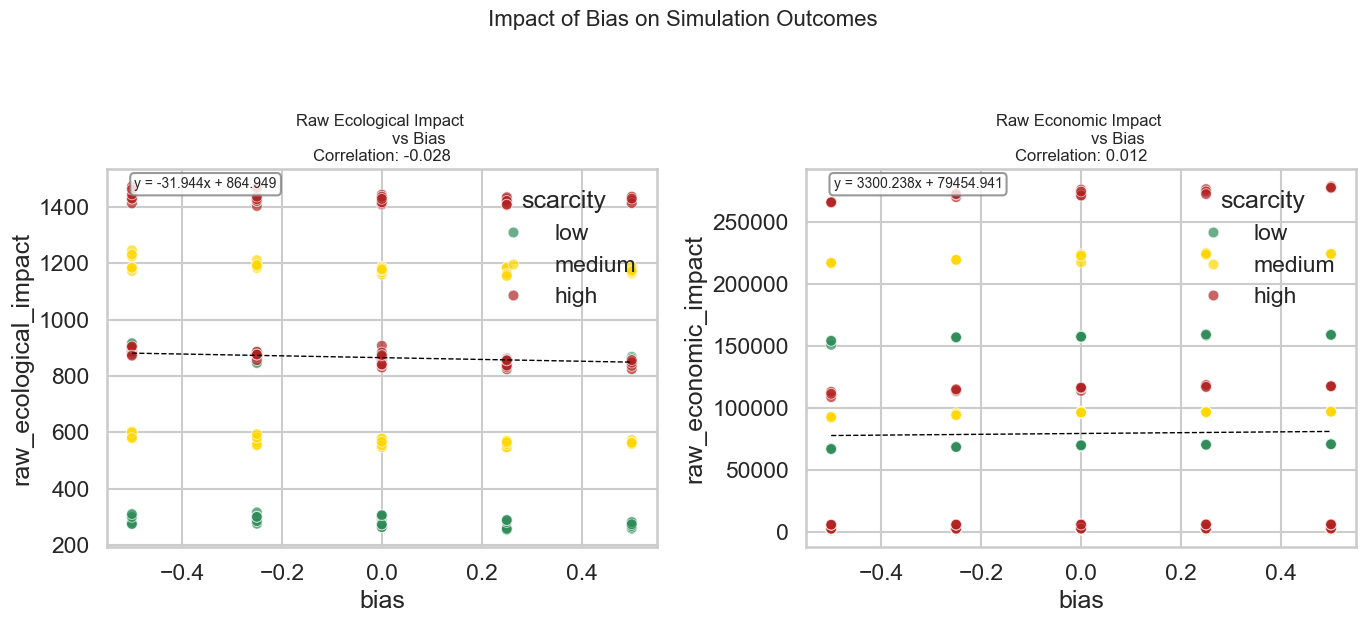

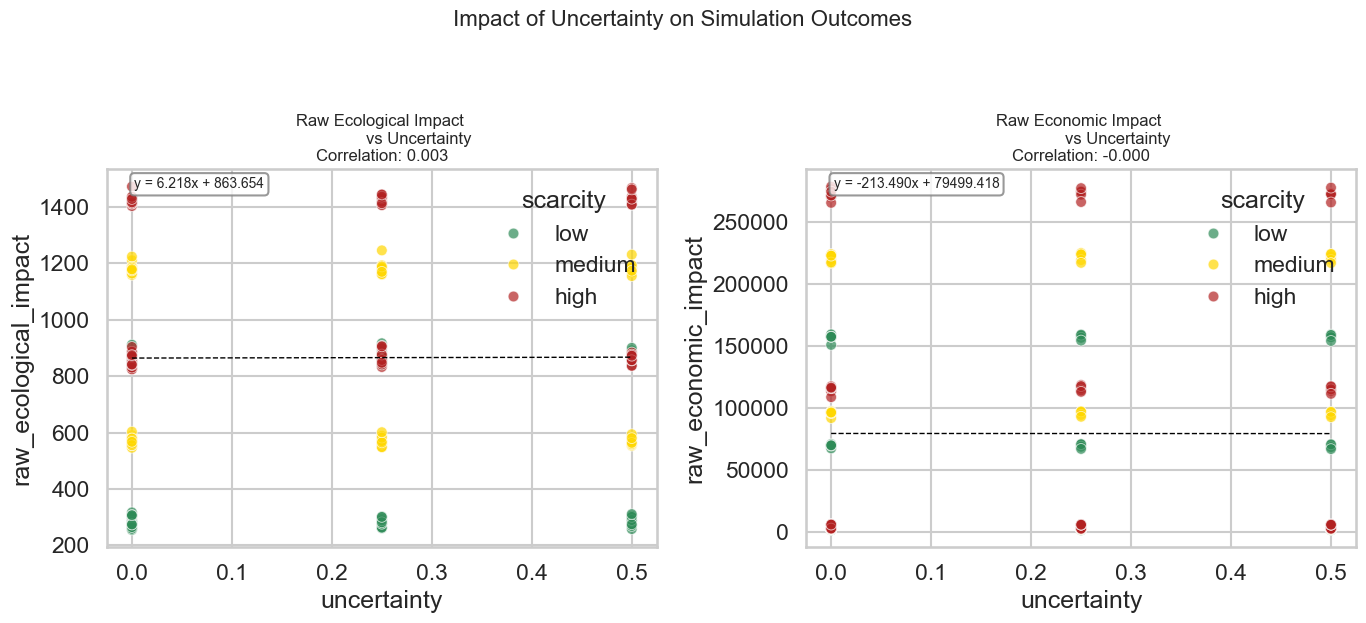

<Figure size 1200x1000 with 0 Axes>

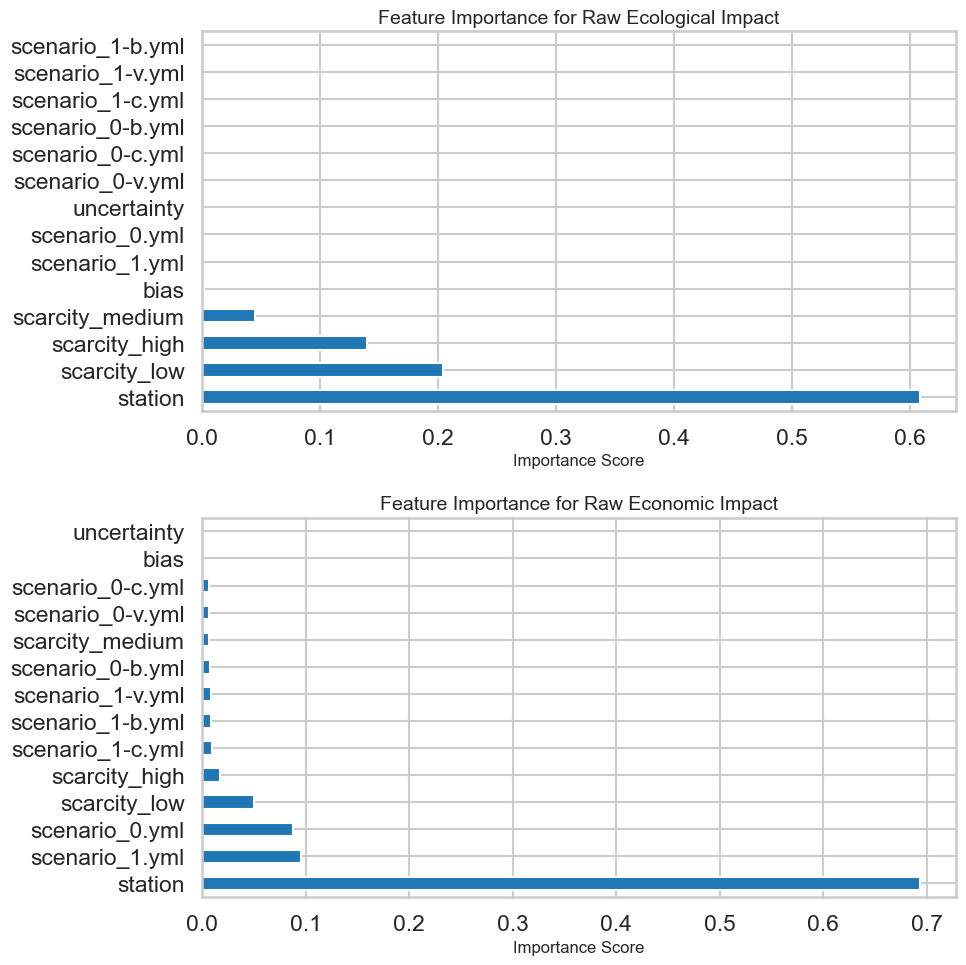

In [42]:
pma.correlation_analysis(results_df)

## Cooperation Analysis
Analyzing cooperation patterns across scenarios and their impact on ecological and economic outcomes.

/Users/timo/PycharmProjects/Hackathon-Water-Scarcity/src/plot_multi_analysis.py:1168: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/timo/envirpython/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


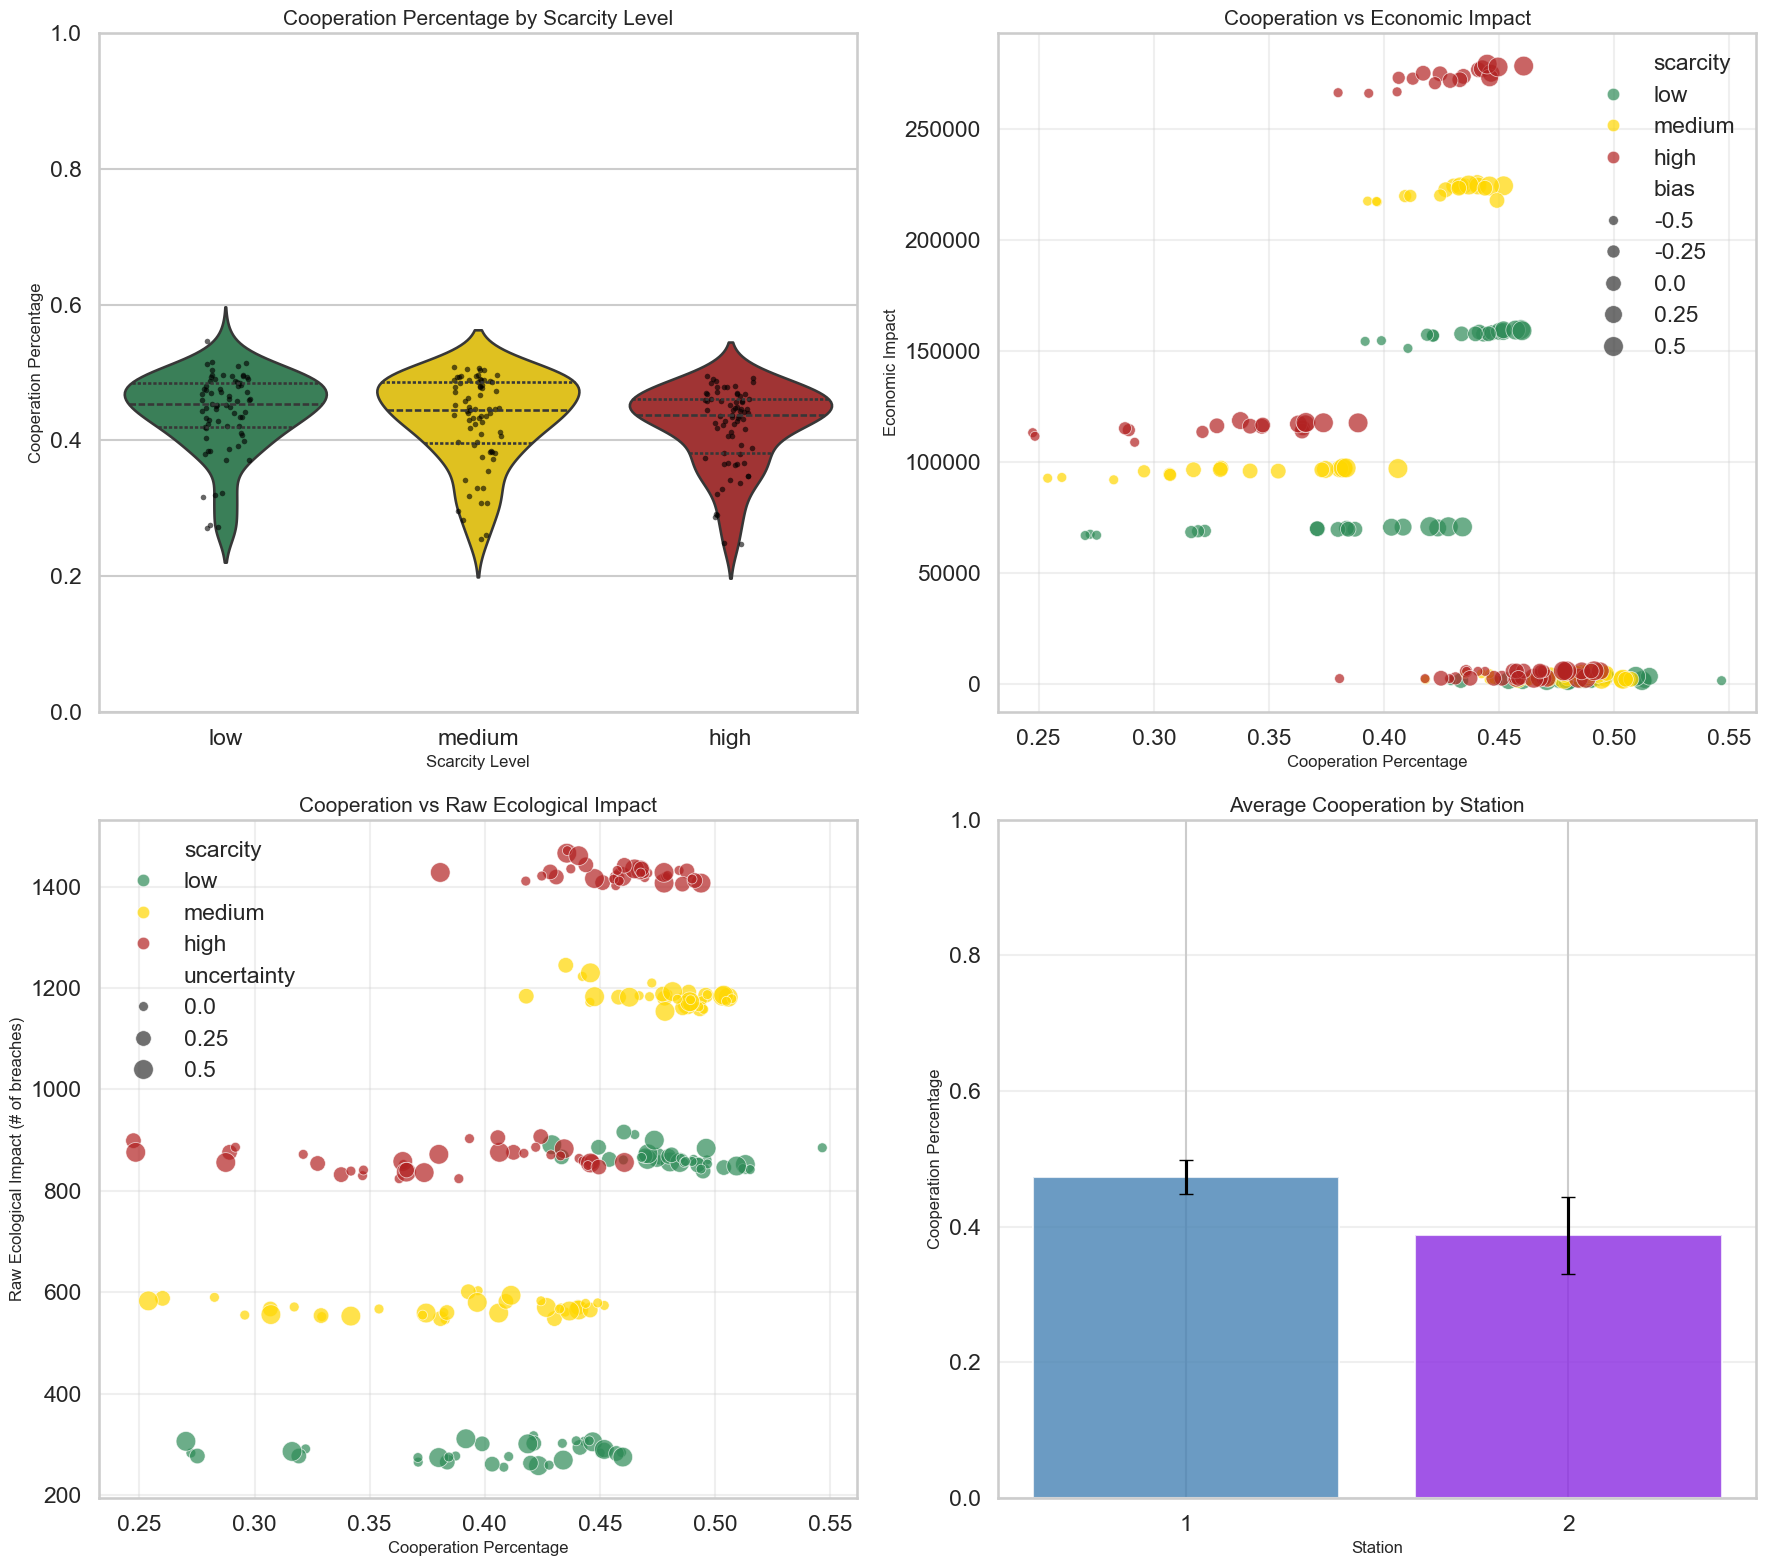

In [43]:
pma.analyze_cooperation_patterns(results_df)

## Raw Impact Vs Scalled Impact
Analyzing the raw (unscaled) ecological / economic impact against scalled impacts 

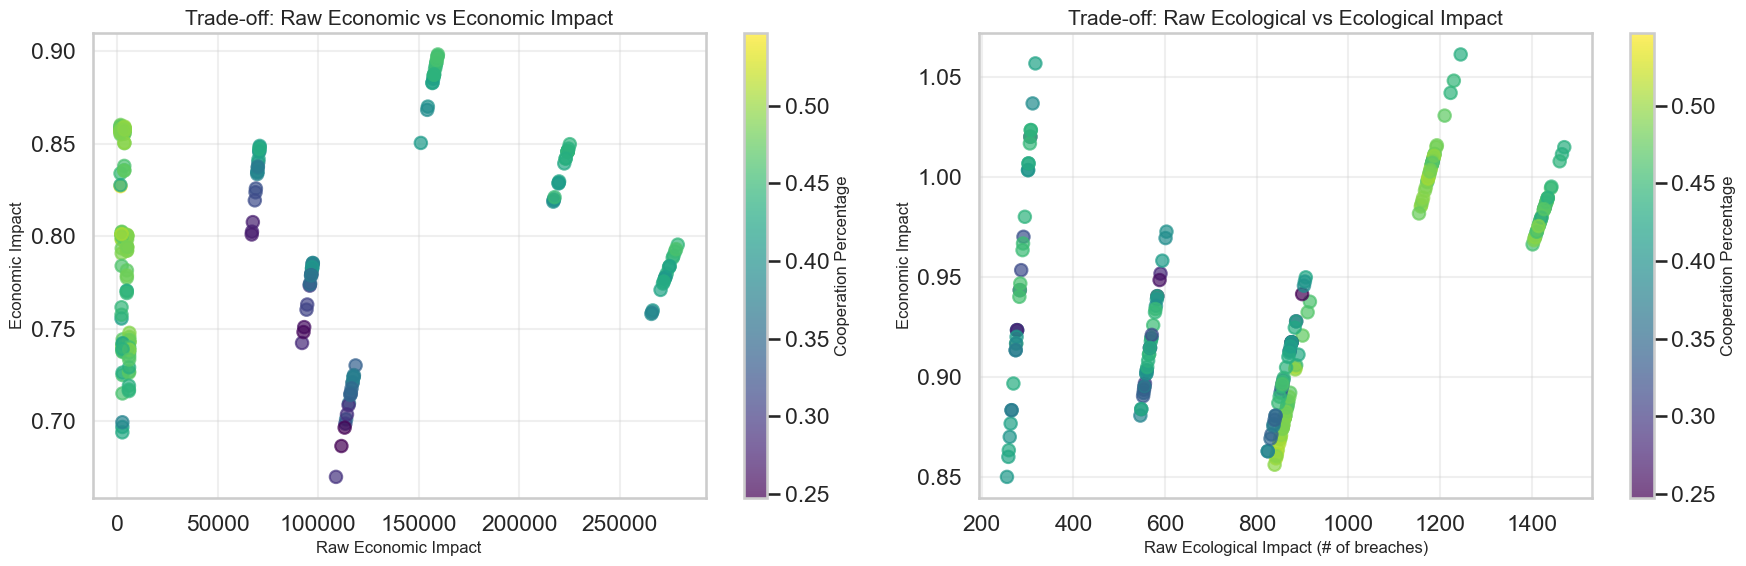

In [44]:
pma.analyze_raw_impact(results_df)

## Cooperation by Forecast Parameters
Analyzing how forecast bias and uncertainty affect cooperation levels.


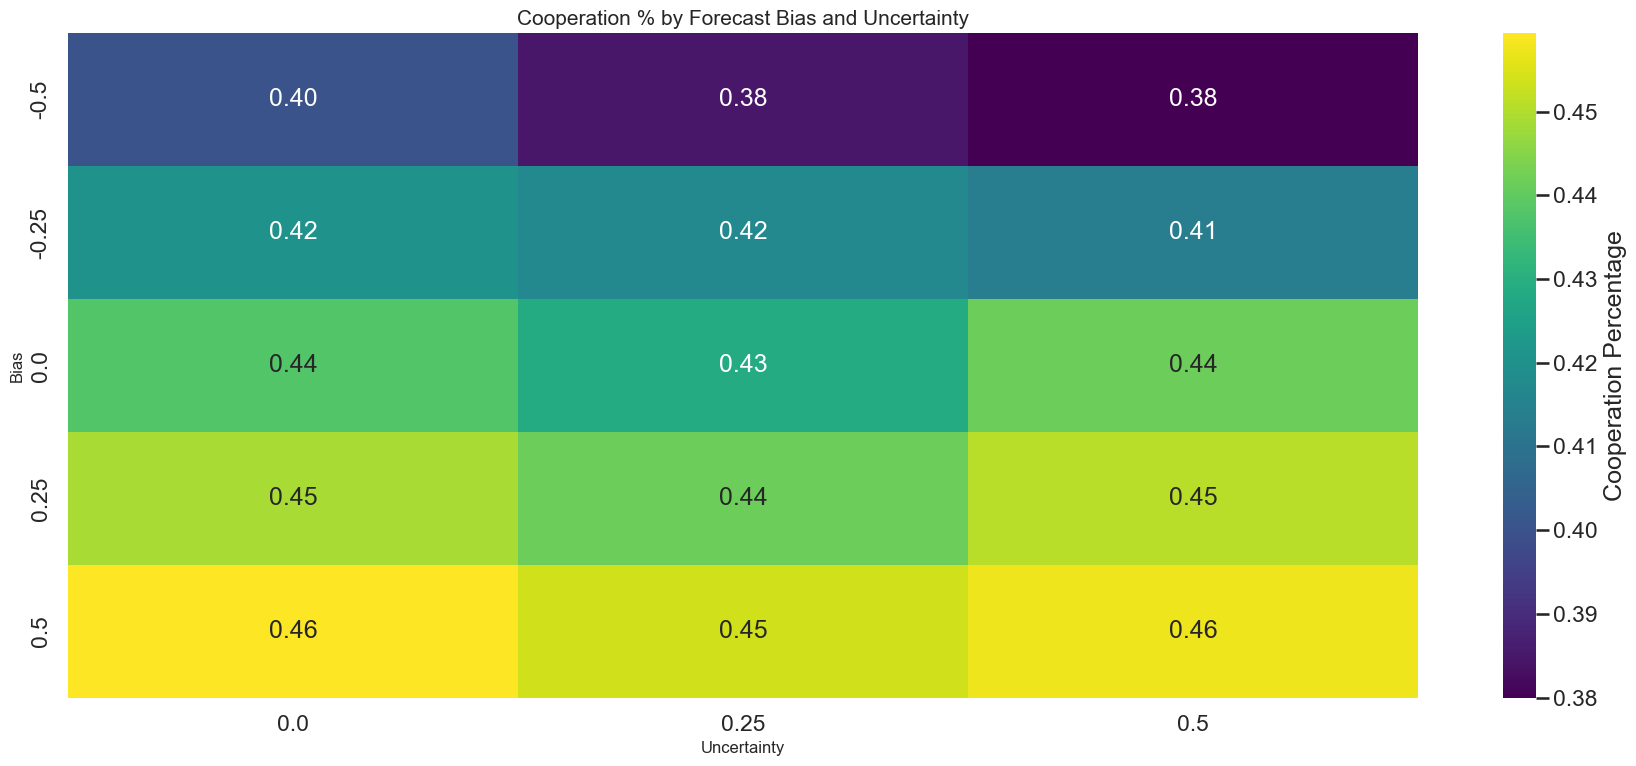

In [45]:
pma.analyze_cooperation_by_forecast_params(results_df)

## Comprehensive Analysis
Performing a comprehensive analysis of all metrics and their relationships.


=== Summary Statistics ===

Overall Metrics:
Average Cooperation: 0.43
Average Raw Ecological Impact: 864.9 breaches
Average Scaled Ecological Impact: 0.940
Average Economic Impact: 79454.941

Correlation Matrix:
                        cooperation_percentage  raw_ecological_impact  \
cooperation_percentage                    1.00                   0.45   
raw_ecological_impact                     0.45                   1.00   
ecological_impact                         0.21                   0.42   
economic_impact                           0.34                  -0.62   
raw_economic_impact                      -0.36                  -0.53   
bias                                      0.35                  -0.03   
uncertainty                              -0.05                   0.00   

                        ecological_impact  economic_impact  \
cooperation_percentage               0.21             0.34   
raw_ecological_impact                0.42            -0.62   
ecological_impac

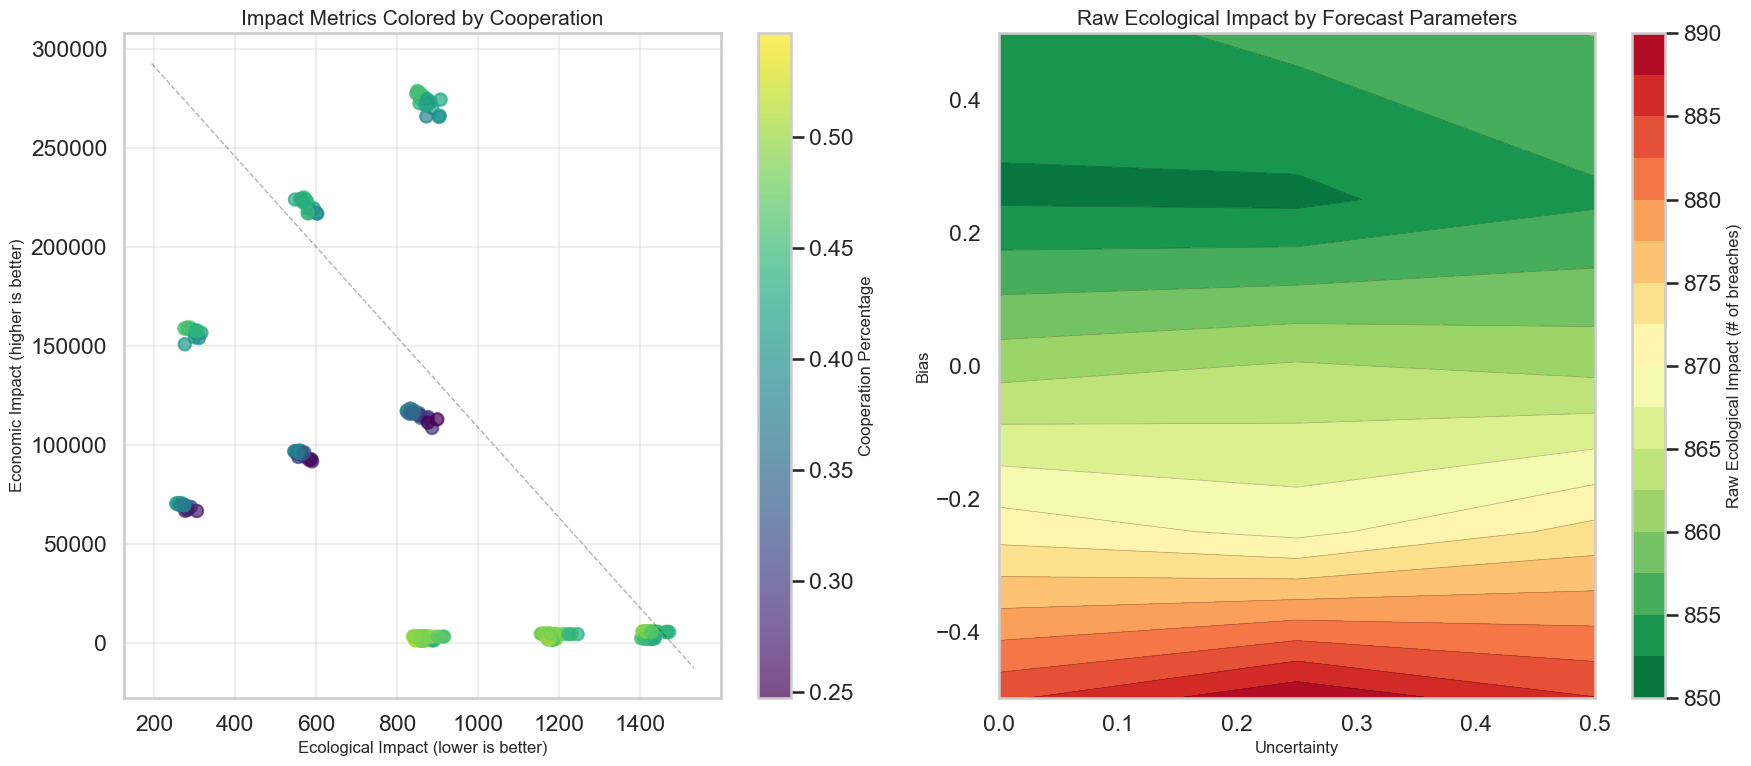

In [46]:
pma.comprehensive_analysis(results_df)

In [1]:
import optuna
import numpy as np
from types import MethodType
import src.core as wms



def objective(trial):
    priority_weights_1 = trial.suggest_float("priority_weights_1", 0.5, 1.5)
    priority_weights_2 = trial.suggest_float("priority_weights_2", 0.1, 1.0)
    priority_weights_3 = trial.suggest_float("priority_weights_3", 0.1, 2.0)

    compression_1 = trial.suggest_float("compression_1", 0.5, 1.0)
    compression_2 = trial.suggest_float("compression_2", 0.05, 0.5)
    compression_3 = trial.suggest_float("compression_3", 0.05, 0.5)
    compression_4 = trial.suggest_float("compression_4", 0.05, 0.5)

    eco_alpha = trial.suggest_float("eco_alpha", 1.0, 3.0)
    eco_beta = trial.suggest_float("eco_beta", 0.5, 2.0)
    fine_scale = trial.suggest_float("fine_scale", 1.0, 4.0)
    overuse_power = trial.suggest_float("overuse_power", 1.5, 4.0)
    subsidy_low = trial.suggest_float("subsidy_low", 0.1, 1.0)
    penalty_low = trial.suggest_float("penalty_low", 1.0, 2.0)
    penalty_medium = trial.suggest_float("penalty_medium", 1.0, 2.0)
    reward_onquota_low = trial.suggest_float("reward_onquota_low", 0.0, 0.01)
    reward_onquota_med = trial.suggest_float("reward_onquota_med", 0.001, 0.01)
    reward_onquota_high = trial.suggest_float("reward_onquota_high", 0.005, 0.03)
    fine_cap_factor = trial.suggest_float("fine_cap_factor", 1.5, 5.0)

    def custom_quota(self, *args, **kwargs):

        return quota_priority_weighted_flexible(
            self, *args, **kwargs,
            priority_weights_1=priority_weights_1,
            priority_weights_2=priority_weights_2,
            priority_weights_3=priority_weights_3,
            compression_1=compression_1,
            compression_2=compression_2,
            compression_3=compression_3,
            compression_4=compression_4
        )

    def custom_incentive(self, *args, **kwargs):
        return incentive_priority_realistic_v3(
            self, *args, **kwargs,
            eco_alpha=eco_alpha,
            eco_beta=eco_beta,
            fine_scale=fine_scale,
            overuse_power=overuse_power,
            subsidy_low=subsidy_low,
            penalty_low=penalty_low,
            penalty_medium=penalty_medium,
            reward_onquota_low=reward_onquota_low,
            reward_onquota_med=reward_onquota_med,
            reward_onquota_high=reward_onquota_high,
            fine_cap_factor=fine_cap_factor
        )

    results_df = sc.run_all_scenarios(
        turns=700,
        iterations=1,
        custom_quota=custom_quota,
        custom_incentive_policy=custom_incentive
    )

    total = len(results_df)
    passed = results_df[results_df["priority_ok"] == 1.0]
    p_ratio = len(passed) / total

    if p_ratio < 0.2:
        return -1e6

    E_eco = passed["ecological_impact"].mean()
    E_econ = passed["economic_impact"].mean()

    score = int(p_ratio * 10) + (E_econ - E_eco)
    with open("trial_log_.csv", "a") as f:
        f.write(f"{trial.params},{trial.number},{score},{p_ratio},{E_eco},{E_econ}\n")
    return score

In [ ]:
initial_params = {
    "priority_weights_1": 1.0,
    "priority_weights_2": 0.4,
    "priority_weights_3": 1.4,
    "compression_1": 0.7,
    "compression_2": 0.15,
    "compression_3": 0.15,
    "compression_4": 0.25,
    "eco_alpha": 2.47,
    "eco_beta": 0.77,
    "fine_scale": 1.5,
    "overuse_power": 3.0,
    "subsidy_low": 0.69,
    "penalty_low": 1.83,
    "penalty_medium": 1.63,
    "reward_onquota_low": 0.0,
    "reward_onquota_med": 0.005,
    "reward_onquota_high": 0.015,
    "fine_cap_factor": 2.5
}

study = optuna.create_study(direction="maximize")
study.enqueue_trial(initial_params)
study.optimize(objective, n_trials=100)

tpe_sampler = optuna.samplers.TPESampler()
study_tpe = optuna.create_study(direction="maximize", sampler=tpe_sampler)
study_tpe.enqueue_trial(initial_params)
study_tpe.optimize(objective, n_trials=100)

cma_sampler = optuna.samplers.CmaEsSampler(
    x0=study_tpe.best_params,
    sigma0=0.2
)
study_cma = optuna.create_study(direction="maximize", sampler=cma_sampler)
study_cma.enqueue_trial(study_tpe.best_params)
study_cma.optimize(objective, n_trials=100)

[I 2025-05-25 00:00:14,469] A new study created in memory with name: no-name-d623b715-6394-4fcb-92c0-0d8311f51e24


Starting simulations across all scenarios...
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.889, Econ Impact: 0.928, Raw Eco Impact: 174.0, Cooperation %: 43.0%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.25, Eco Impact: 0.899, Econ Impact: 0.927, Raw Eco Impact: 176.0, Cooperation %: 49.3%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.5, Eco Impact: 0.894, Econ Impact: 0.930, Raw Eco Impact: 175.0, Cooperation %: 52.5%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.0, Eco Impact: 0.899, Econ Impact: 0.930, Raw Eco Impact: 176.0, Cooperation %: 45.8%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.25, Eco Impact: 0.884, Econ Impact: 0.927, Raw Eco Impact: 173.0, Cooperation %: 50.8%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.5, Ec

[I 2025-05-25 00:05:05,118] Trial 0 finished with value: 5.691191259604559 and parameters: {'priority_weights_1': 1.0, 'priority_weights_2': 0.4, 'priority_weights_3': 1.4, 'compression_1': 0.7, 'compression_2': 0.15, 'compression_3': 0.15, 'compression_4': 0.25, 'eco_alpha': 2.47, 'eco_beta': 0.77, 'fine_scale': 1.5, 'overuse_power': 3.0, 'subsidy_low': 0.69, 'penalty_low': 1.83, 'penalty_medium': 1.63, 'reward_onquota_low': 0.0, 'reward_onquota_med': 0.005, 'reward_onquota_high': 0.015, 'fine_cap_factor': 2.5}. Best is trial 0 with value: 5.691191259604559.


Scenario: 1-c.yml, Station: 2, Scarcity: high, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.859, Econ Impact: -1.464, Raw Eco Impact: 164.0, Cooperation %: 56.6%, satisfaction: 0.0
Completed 216 simulation runs
Starting simulations across all scenarios...
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.947, Econ Impact: 0.293, Raw Eco Impact: 185.0, Cooperation %: 33.6%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.25, Eco Impact: 0.905, Econ Impact: 0.273, Raw Eco Impact: 177.0, Cooperation %: 46.7%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.5, Eco Impact: 0.889, Econ Impact: 0.241, Raw Eco Impact: 174.0, Cooperation %: 58.2%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.0, Eco Impact: 0.926, Econ Impact: 0.261, Raw Eco Impact: 181.0, Cooperation %: 47.6%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, 

[I 2025-05-25 00:09:54,592] Trial 1 finished with value: 2.5169339406359947 and parameters: {'priority_weights_1': 0.7574626336740087, 'priority_weights_2': 0.831141996131111, 'priority_weights_3': 1.6487655746618284, 'compression_1': 0.8589440755116282, 'compression_2': 0.11508208207208899, 'compression_3': 0.23053773653625625, 'compression_4': 0.3628580832554213, 'eco_alpha': 2.4317453093395036, 'eco_beta': 1.5235535310577017, 'fine_scale': 2.817130793625734, 'overuse_power': 1.854613324437558, 'subsidy_low': 0.6108585058396653, 'penalty_low': 1.836181165135517, 'penalty_medium': 1.388452721739603, 'reward_onquota_low': 0.004840821558282025, 'reward_onquota_med': 0.00954568919920501, 'reward_onquota_high': 0.029523462641163067, 'fine_cap_factor': 4.967876814352939}. Best is trial 0 with value: 5.691191259604559.


...

Scenario: 1-c.yml, Station: 2, Scarcity: high, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.953, Econ Impact: 0.684, Raw Eco Impact: 182.0, Cooperation %: 39.6%, satisfaction: 0.0
Completed 216 simulation runs
Starting simulations across all scenarios...
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.852, Econ Impact: -0.471, Raw Eco Impact: 167.0, Cooperation %: 46.8%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.25, Eco Impact: 0.889, Econ Impact: -0.474, Raw Eco Impact: 174.0, Cooperation %: 49.0%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.5, Eco Impact: 0.873, Econ Impact: -0.438, Raw Eco Impact: 171.0, Cooperation %: 40.3%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.0, Eco Impact: 0.894, Econ Impact: -0.453, Raw Eco Impact: 175.0, Cooperation %: 38.8%, satisfaction: 1.0
Scenario: 0.yml, Station: 1, Scarcity: lo

[I 2025-05-25 00:19:28,708] Trial 3 finished with value: 3.1518886759057603 and parameters: {'priority_weights_1': 0.8017124880019341, 'priority_weights_2': 0.5248348647320008, 'priority_weights_3': 1.2069327450683136, 'compression_1': 0.5479064776691638, 'compression_2': 0.11461130047760906, 'compression_3': 0.42638179744138016, 'compression_4': 0.057929406563326645, 'eco_alpha': 2.5565474402186967, 'eco_beta': 1.3656751650778145, 'fine_scale': 3.654346111136369, 'overuse_power': 1.873122224364251, 'subsidy_low': 0.40166279069272703, 'penalty_low': 1.560307082562582, 'penalty_medium': 1.3168130339750261, 'reward_onquota_low': 0.007444220855794288, 'reward_onquota_med': 0.004350965331751715, 'reward_onquota_high': 0.008490522677273847, 'fine_cap_factor': 4.412483493348523}. Best is trial 0 with value: 5.691191259604559.


Scenario: 1-c.yml, Station: 2, Scarcity: high, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.969, Econ Impact: 0.559, Raw Eco Impact: 185.0, Cooperation %: 37.4%, satisfaction: 0.0
Completed 216 simulation runs
Starting simulations across all scenarios...
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.958, Econ Impact: 0.037, Raw Eco Impact: 187.0, Cooperation %: 45.7%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.25, Eco Impact: 1.000, Econ Impact: 0.109, Raw Eco Impact: 195.0, Cooperation %: 28.7%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.5, Eco Impact: 0.963, Econ Impact: 0.043, Raw Eco Impact: 188.0, Cooperation %: 44.9%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.0, Eco Impact: 0.968, Econ Impact: 0.058, Raw Eco Impact: 189.0, Cooperation %: 38.0%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, B

[I 2025-05-25 00:24:15,871] Trial 4 finished with value: -1000000.0 and parameters: {'priority_weights_1': 0.7514390936962336, 'priority_weights_2': 0.7885375934987837, 'priority_weights_3': 0.7195899204576113, 'compression_1': 0.8275185593912844, 'compression_2': 0.36231538236147615, 'compression_3': 0.19904804190693254, 'compression_4': 0.09636713990009152, 'eco_alpha': 2.6640286009819247, 'eco_beta': 1.4340395964547528, 'fine_scale': 3.69677468419074, 'overuse_power': 1.8244217656733075, 'subsidy_low': 0.2875240312624745, 'penalty_low': 1.2084232020381422, 'penalty_medium': 1.787532059500244, 'reward_onquota_low': 0.007474830430380012, 'reward_onquota_med': 0.0016013771189845468, 'reward_onquota_high': 0.012558528415095452, 'fine_cap_factor': 4.488893688505901}. Best is trial 0 with value: 5.691191259604559.


Scenario: 1-c.yml, Station: 2, Scarcity: high, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.995, Econ Impact: 0.753, Raw Eco Impact: 190.0, Cooperation %: 40.2%, satisfaction: 0.0
Completed 216 simulation runs
Starting simulations across all scenarios...
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.0, Eco Impact: 0.905, Econ Impact: 0.583, Raw Eco Impact: 177.0, Cooperation %: 48.0%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.25, Eco Impact: 0.910, Econ Impact: 0.589, Raw Eco Impact: 178.0, Cooperation %: 43.0%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.0, Uncertainty: 0.5, Eco Impact: 0.894, Econ Impact: 0.570, Raw Eco Impact: 175.0, Cooperation %: 55.0%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, Bias: 0.25, Uncertainty: 0.0, Eco Impact: 0.910, Econ Impact: 0.593, Raw Eco Impact: 178.0, Cooperation %: 41.1%, satisfaction: 0.0
Scenario: 0.yml, Station: 1, Scarcity: low, B

In [7]:
import optuna
import pandas as pd
from optuna.trial import TrialState
from optuna.storages import InMemoryStorage

rows = []
with open("trial_log.csv", "r") as f:
    for line in f:
        parts = line.strip().split("},")
        if len(parts) < 2:
            continue
        param_str = parts[0] + "}"
        rest = parts[1].strip().split(",")
        rows.append({
            "params": param_str,
            "number": int(rest[0]),
            "score": float(rest[1]),
            "p_ratio": float(rest[2]),
            "E_eco": float(rest[3]),
            "E_econ": float(rest[4])
        })

log_df = pd.DataFrame(rows)


In [20]:
import ast
from optuna.distributions import FloatDistribution

# log_df["params"] = log_df["params"].apply(ast.literal_eval)

study = optuna.create_study(direction="maximize")

for _, row in log_df.iterrows():
    trial_id = study._storage.create_new_trial(study._study_id)

    for name, val in row["params"].items():
        study._storage.set_trial_param(
            trial_id,
            name,
            val,
            FloatDistribution(low=0.0, high=100.0)
        )

    study._storage.set_trial_state_values(
        trial_id,
        state=TrialState.COMPLETE,
        values=[row["score"]]
    )

[I 2025-05-25 10:10:28,974] A new study created in memory with name: no-name-b5612e39-03f3-4040-a9fa-c87ac750730d


In [1]:
study.optimize(objective, n_trials=500)